<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
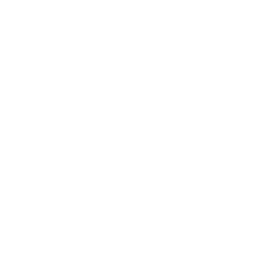
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analiza wzorców głosowania w obwodach wyborczych</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Administracja publiczna / Statystyka wyborcza &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Streszczenie

Analiza ta bada, czy przynależność partyjna zmienia się systematycznie
w zależności od typu obwodu (miejski, podmiejski, wiejski) w symulowanym
zbiorze danych wyborczych z 100 obwodów w hrabstwie. Ponieważ kilka komórek
partia-według-typu jest rzadkich — najmniejsze komórki tablicy krzyżowej
zawierają zaledwie jeden lub dwa obwody, z licznościami oczekiwanymi
poniżej pięciu — ogólny test chi-kwadrat Pearsona dla ogólnego związku jest
tu niedomocny i niewiarygodny. Uzupełniamy go zatem **testem trendu
Cochrana-Armitage**, skoncentrowanym testem o jednym stopniu swobody, który
wykorzystuje naturalne uporządkowanie miejski-do-wiejski i zadaje ostrzejsze
pytanie: czy poparcie dla Partii A maleje monotonicznie wzdłuż tego
gradientu? Test trendu podaje dokładną wartość p, co jest właściwym
wnioskowaniem, gdy liczności komórek są małe. Kontrast między obydwoma
testami jest analitycznym sednem tego przykładu: ogólny test związku może
przeoczyć rzeczywisty wzorzec kierunkowy, który wykrywa uporządkowany test
trendu.


## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Rekordy na poziomie obwodu, jeden wiersz na obwód, z typem obwodu, hrabstwem i partią większościową | 100 |

Środowisko wykonawcze działa w trybie bez licencji, co ogranicza wynik do
100 obserwacji; analiza jest zaprojektowana wokół tej próby na poziomie
obwodu, tak aby komórki tablicy krzyżowej były naprawdę małe, a dokładny
test trendu był naturalnym narzędziem.


---

In [1]:
/* --------------------------------------------------------
   Wygeneruj syntetyczne dane o głosowaniu na poziomie obwodu
   Małe liczności w obwodach wiejskich, aby zademonstrować
   potrzebę dokładnych testów
   -------------------------------------------------------- */
DANE work.precinct_votes;
    DŁUGOŚĆ county_name $15 precinct_type $10 party $16;
    CALL streaminit(42);
    TABLICA party_list[4] $16 _temporary_ ('PARTIA_A' 'PARTIA_B' 'PARTIA_C' 'NIEZALEŻNY');
    TABLICA type_list[3] $10 _temporary_ ('MIEJSKI' 'PODMIEJSKI' 'WIEJSKI');
    TABLICA county_list[5] $15 _temporary_ ('JEFFERSON' 'HAMILTON' 'MADISON' 'ADAMS' 'MONROE');
    POWTÓRZ precinct_seq = 1 TO 500;
        precinct_id = cat('PCT-', ZAPISZ(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Przypisz typ obwodu z wagami */
        type_prob = rand('uniform');
        JEŚLI type_prob < 0.30 WTEDY precinct_type = 'MIEJSKI';
        PRZECIWNIE JEŚLI type_prob < 0.65 WTEDY precinct_type = 'PODMIEJSKI';
        PRZECIWNIE precinct_type = 'WIEJSKI';
        /* Przypisz partię z rozkładem zależnym od typu obwodu */
        party_prob = rand('uniform');
        JEŚLI precinct_type = 'MIEJSKI' WTEDY POWTÓRZ;
            JEŚLI party_prob < 0.55 WTEDY party = 'PARTIA_A';
            PRZECIWNIE JEŚLI party_prob < 0.80 WTEDY party = 'PARTIA_B';
            PRZECIWNIE JEŚLI party_prob < 0.92 WTEDY party = 'PARTIA_C';
            PRZECIWNIE party = 'NIEZALEŻNY';
        KONIEC;
        PRZECIWNIE JEŚLI precinct_type = 'PODMIEJSKI' WTEDY POWTÓRZ;
            JEŚLI party_prob < 0.40 WTEDY party = 'PARTIA_A';
            PRZECIWNIE JEŚLI party_prob < 0.75 WTEDY party = 'PARTIA_B';
            PRZECIWNIE JEŚLI party_prob < 0.88 WTEDY party = 'PARTIA_C';
            PRZECIWNIE party = 'NIEZALEŻNY';
        KONIEC;
        PRZECIWNIE POWTÓRZ; /* WIEJSKI -- mniejsze komórki dla partii mniejszościowych */
            JEŚLI party_prob < 0.25 WTEDY party = 'PARTIA_A';
            PRZECIWNIE JEŚLI party_prob < 0.70 WTEDY party = 'PARTIA_B';
            PRZECIWNIE JEŚLI party_prob < 0.85 WTEDY party = 'PARTIA_C';
            PRZECIWNIE party = 'NIEZALEŻNY';
        KONIEC;
        /* Liczba głosów zależy od typu obwodu */
        JEŚLI precinct_type = 'MIEJSKI' WTEDY
            vote_count = int(rand('normal', 120, 40));
        PRZECIWNIE JEŚLI precinct_type = 'PODMIEJSKI' WTEDY
            vote_count = int(rand('normal', 80, 25));
        PRZECIWNIE
            vote_count = int(rand('normal', 25, 12));
        JEŚLI vote_count < 1 WTEDY vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        WYJŚCIE;
    KONIEC;
    USUŃ precinct_seq county_idx type_prob party_prob;
WYKONAJ;



NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.15 seconds
  cpu   0.15 seconds


---

                                                   The FREQ Procedure

Typ obwodu    Frequency    Percent
-----------------------------------
MIEJSKI              29     29.00
PODMIEJSKI           37     37.00
WIEJSKI              34     34.00

Partia         Frequency    Percent
------------------------------------
NIEZALEŻNY             9      9.00
PARTIA_A              45     45.00
PARTIA_B              34     34.00
PARTIA_C              12     12.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


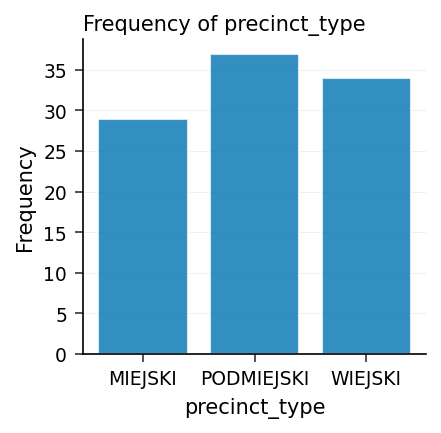

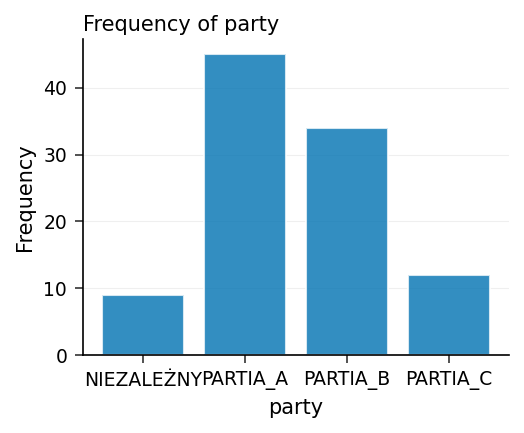

In [2]:
/* --------------------------------------------------------
   Bazowy rozkład typu obwodu i partii
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    ETYKIETA precinct_type="Typ obwodu" party="Partia";
WYKONAJ;


---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


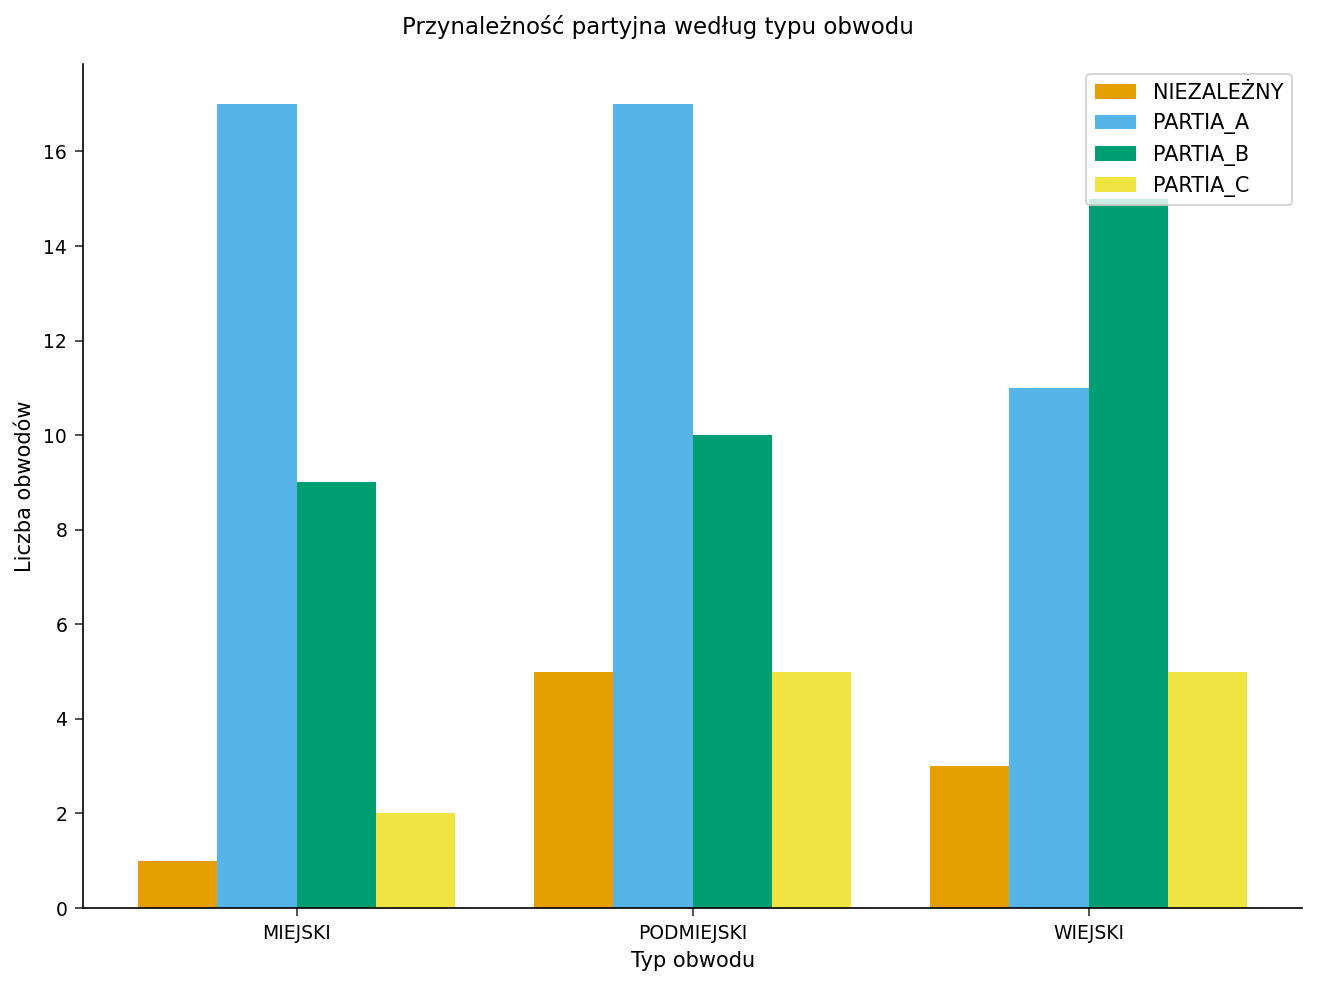

In [3]:
/* --------------------------------------------------------
   Przynależność partyjna według typu obwodu (liczba obwodów)
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=CZĘSTOŚCI;
    XAXIS ETYKIETA='Typ obwodu';
    YAXIS ETYKIETA='Liczba obwodów';
    TYTUŁ 'Przynależność partyjna według typu obwodu';
WYKONAJ;


---

                         Typ obwodu według partii: tabela krzyżowa z licznościami oczekiwanymi                          

                                                   The FREQ Procedure

Table of Typ obwodu by Partia

Typ obwodu | NIEZALEŻNY |   PARTIA_A |   PARTIA_B |   PARTIA_C |       Total
-----------+------------+------------+------------+------------+------------
MIEJSKI    |          1 |         17 |          9 |          2 |          29
           |       1.00 |      17.00 |       9.00 |       2.00 |       29.00
           |       2.61 |      13.05 |       9.86 |       3.48 |            
           |       3.45 |      58.62 |      31.03 |       6.90 |      100.00
           |      11.11 |      37.78 |      26.47 |      16.67 |       29.00
-----------+------------+------------+------------+------------+------------
PODMIEJSKI |          5 |         17 |         10 |          5 |          37
           |       5.00 |      17.00 |      10.00 |       5.00 |       37.00
      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


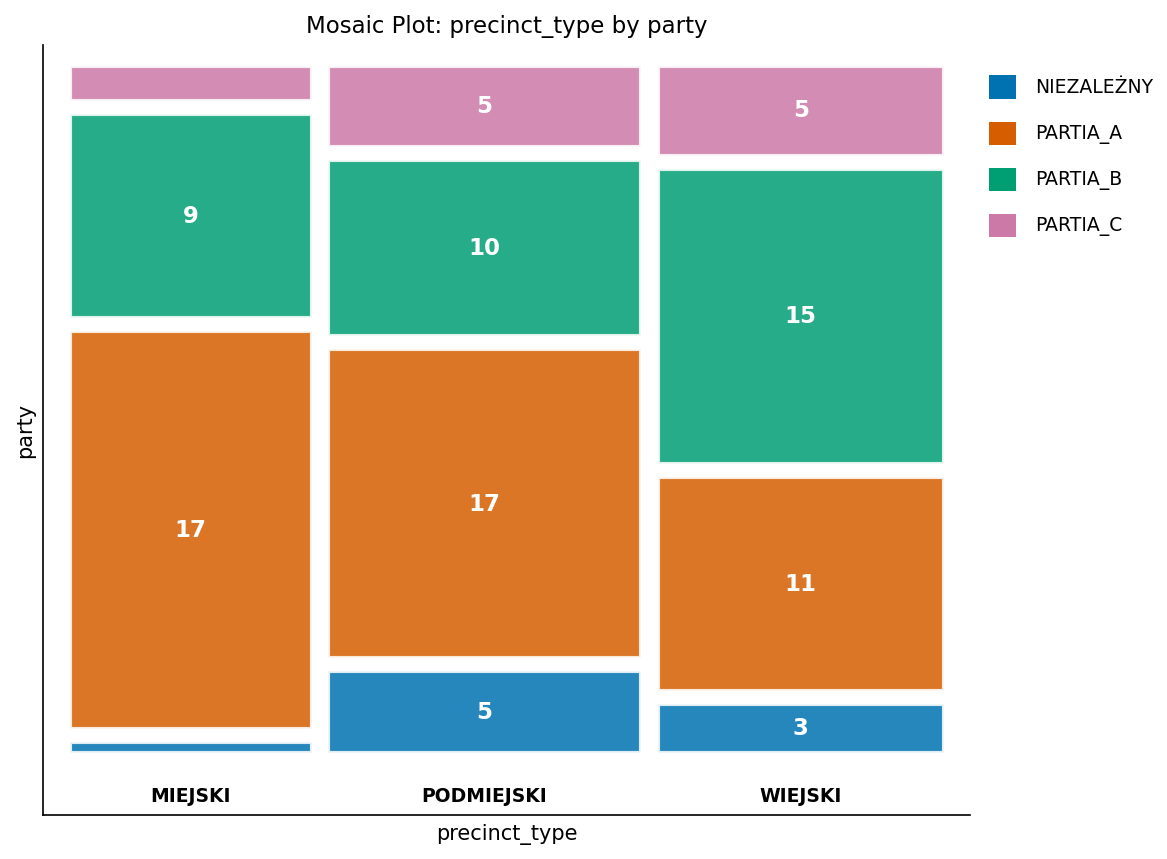

In [4]:
/* --------------------------------------------------------
   Tabela krzyżowa typ obwodu x partia.
   Zażądaj liczności OCZEKIWANYCH, aby widoczne były rzadkie
   komórki, plus asymptotyczny test chi-kwadrat Pearsona dla
   ogólnego związku. Zwróć uwagę na małe liczności oczekiwane
   w kolumnach NIEZALEŻNY i PARTIA_C -- to sygnał, że lepszym
   narzędziem wnioskowania jest uporządkowany, dokładny test
   trendu.
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    ETYKIETA precinct_type="Typ obwodu" party="Partia";
    TYTUŁ 'Typ obwodu według partii: tabela krzyżowa z licznościami oczekiwanymi';
WYKONAJ;


                     Test trendu Cochrana-Armitage: poparcie dla Partii A wzdłuż gradientu obwodów                      

                                                   The FREQ Procedure

Table of Kolejność typu obwodu by Flaga Partii A

Kolejność typu obwodu   |         0 |         1 |      Total
------------------------+-----------+-----------+-----------
1                       |        12 |        17 |         29
                        |     12.00 |     17.00 |      29.00
                        |     41.38 |     58.62 |     100.00
                        |     21.82 |     37.78 |      29.00
------------------------+-----------+-----------+-----------
2                       |        20 |        17 |         37
                        |     20.00 |     17.00 |      37.00
                        |     54.05 |     45.95 |     100.00
                        |     36.36 |     37.78 |      37.00
------------------------+-----------+-----------+-----------
3                       |


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


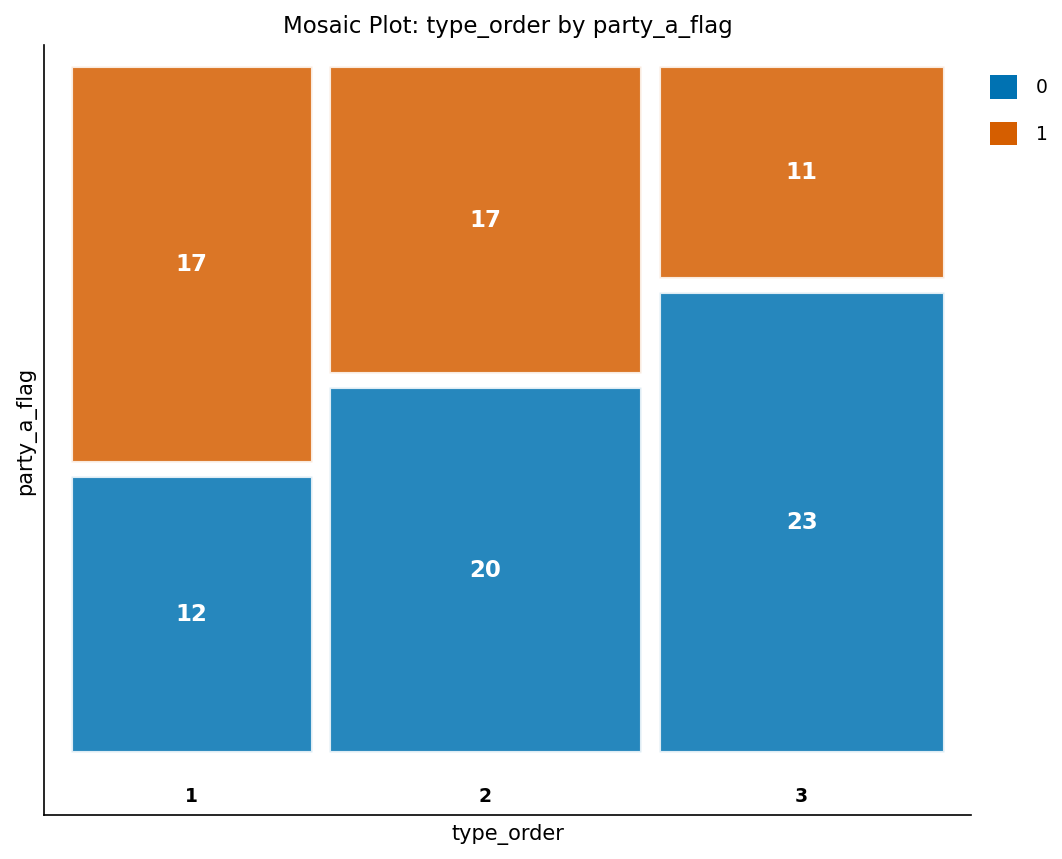

In [5]:
/* --------------------------------------------------------
   Test trendu Cochrana-Armitage. Przekoduj typ obwodu na skalę
   porządkową (1=Miejski, 2=Podmiejski, 3=Wiejski) i sprawdź, czy
   poparcie dla Partii A wykazuje monotoniczny trend wzdłuż
   gradientu. EXACT TREND żąda dokładnej wartości p, właściwej
   przy małych licznościach komórek.
   -------------------------------------------------------- */
DANE work.precinct_ordinal;
    USTAW work.precinct_votes;
    /* Kodowanie porządkowe: 1=Miejski, 2=Podmiejski, 3=Wiejski */
    JEŚLI precinct_type = 'MIEJSKI' WTEDY type_order = 1;
    PRZECIWNIE JEŚLI precinct_type = 'PODMIEJSKI' WTEDY type_order = 2;
    PRZECIWNIE type_order = 3;
    /* Wynik binarny: Partia A vs. wszystkie pozostałe przynależności */
    party_a_flag = (party = 'PARTIA_A');
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    ETYKIETA type_order="Kolejność typu obwodu" party_a_flag="Flaga Partii A";
    TYTUŁ 'Test trendu Cochrana-Armitage: poparcie dla Partii A wzdłuż gradientu obwodów';
WYKONAJ;


                                         Rozkład typu obwodu w ramach hrabstwa                                          

                                                   The FREQ Procedure

Table of Hrabstwo by Typ obwodu

Hrabstwo  |   MIEJSKI |PODMIEJSKI |   WIEJSKI |      Total
----------+-----------+-----------+-----------+-----------
ADAMS     |         4 |        10 |         5 |         19
          |      4.00 |     10.00 |      5.00 |      19.00
          |     21.05 |     52.63 |     26.32 |     100.00
          |     13.79 |     27.03 |     14.71 |      19.00
----------+-----------+-----------+-----------+-----------
HAMILTON  |         7 |         7 |         7 |         21
          |      7.00 |      7.00 |      7.00 |      21.00
          |     33.33 |     33.33 |     33.33 |     100.00
          |     24.14 |     18.92 |     20.59 |      21.00
----------+-----------+-----------+-----------+-----------
JEFFERSON |         7 |         7 |         4 |         18
       


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


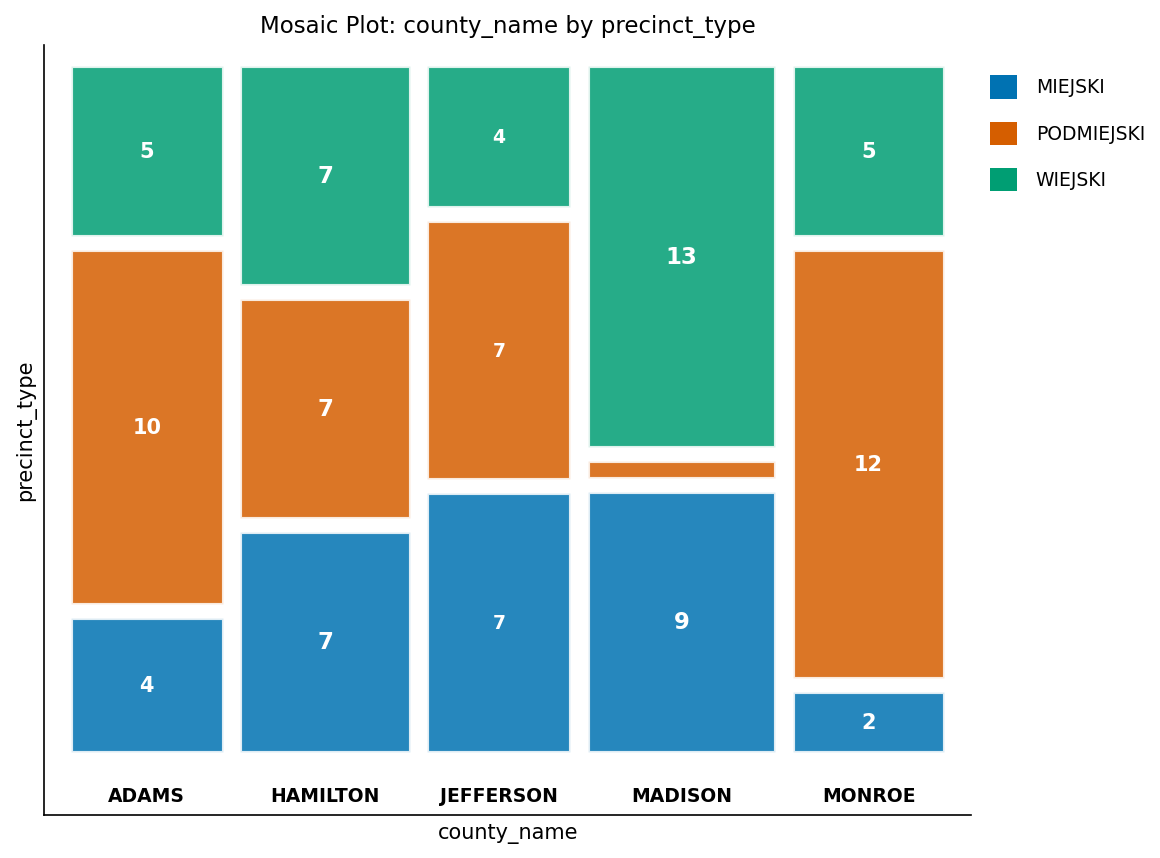

In [6]:
/* --------------------------------------------------------
   Widok na poziomie hrabstwa: jak mieszanka miejski/podmiejski/
   wiejski zmienia się w pięciu hrabstwach. Kontekstualizuje to
   wynik trendu -- gradient obwodów jest obecny w każdym hrabstwie,
   ale jego skład się różni.
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    ETYKIETA county_name="Hrabstwo" precinct_type="Typ obwodu";
    TYTUŁ 'Rozkład typu obwodu w ramach hrabstwa';
WYKONAJ;


---

### Interpretacja

Wśród 100 obwodów Partia A ma ogólną przewagę (45 obwodów), a następnie
Partia B (34), Partia C (12) i niezależni (9). Tabela krzyżowa pokazuje,
że udział Partii A podąża wyraźnym gradientem miejski-do-wiejski: stanowi
58,6% obwodów miejskich, 46,0% obwodów podmiejskich i 32,4% obwodów
wiejskich, podczas gdy Partia B porusza się w przeciwnym kierunku, rosnąc
z 31,0% w obwodach miejskich do 44,1% w wiejskich.

Ogólny test chi-kwadrat Pearsona dla ogólnego związku **nie** jest
statystycznie istotny (chi-kwadrat = 6,78, 6 stopni swobody, p = 0,3418;
V Craméra = 0,18). Ten wynik jest też niepewny: wyświetlenie liczności
oczekiwanych ujawnia kilka komórek poniżej pięciu — na przykład kolumna
niezależnych ma liczności oczekiwane 3,06, 3,33 i 2,61, a niezależni w
obwodach miejskich liczą zaledwie jeden obwód — więc przybliżenie
chi-kwadrat dla dużej próby jest tu niewiarygodne.

Test trendu Cochrana-Armitage doprecyzowuje pytanie, wykorzystując
porządkowe skalowanie miejski-podmiejski-wiejski. Wykrywa on monotoniczny
spadek poparcia dla Partii A, którego nie wykrywa test ogólny: chi-kwadrat
trendu = 4,38 z asymptotycznym Pr > ChiSq = 0,0363 i **dokładnym
Pr >= |Z| = 0,0431**, istotnym na poziomie 0,05. To jest analityczna
korzyść — skoncentrowany, dokładny test o jednym stopniu swobody odzyskuje
rzeczywisty sygnał kierunkowy, którego nie wykrywa ogólny test związku
o 6 stopniach swobody, osłabiony rzadkimi komórkami.

Widok na poziomie hrabstwa potwierdza, że podział miejski/podmiejski/wiejski
jest obecny we wszystkich pięciu hrabstwach, choć mieszanka się różni:
Madison jest najbardziej wiejskie (13 z 23 obwodów wiejskich), podczas gdy
Monroe jest najbardziej podmiejskie (12 z 19). Dla oceny wpływu zmiany
granic okręgów wniosek jest taki, że zmiany granic przesuwające obwody
wzdłuż osi miejski-wiejski mierzalnie zmieniłyby skład partyjny, a ten
geograficzny trend najlepiej dokumentuje dokładny test trendu, a nie
ogólny chi-kwadrat.


---

                                         Rozkład typu obwodu w ramach hrabstwa                                          

                                                   The FREQ Procedure

Table of precinct_type by party

precinct_type | NIEZALEŻNY |   PARTIA_A |   PARTIA_B |   PARTIA_C |       Total
--------------+------------+------------+------------+------------+------------
MIEJSKI       |          1 |         17 |          9 |          2 |          29
              |       1.00 |      17.00 |       9.00 |       2.00 |       29.00
              |       3.45 |      58.62 |      31.03 |       6.90 |      100.00
              |      11.11 |      37.78 |      26.47 |      16.67 |       29.00
--------------+------------+------------+------------+------------+------------
PODMIEJSKI    |          5 |         17 |         10 |          5 |          37
              |       5.00 |      17.00 |      10.00 |       5.00 |       37.00
              |      13.51 |      45.95 |      27.03 |


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


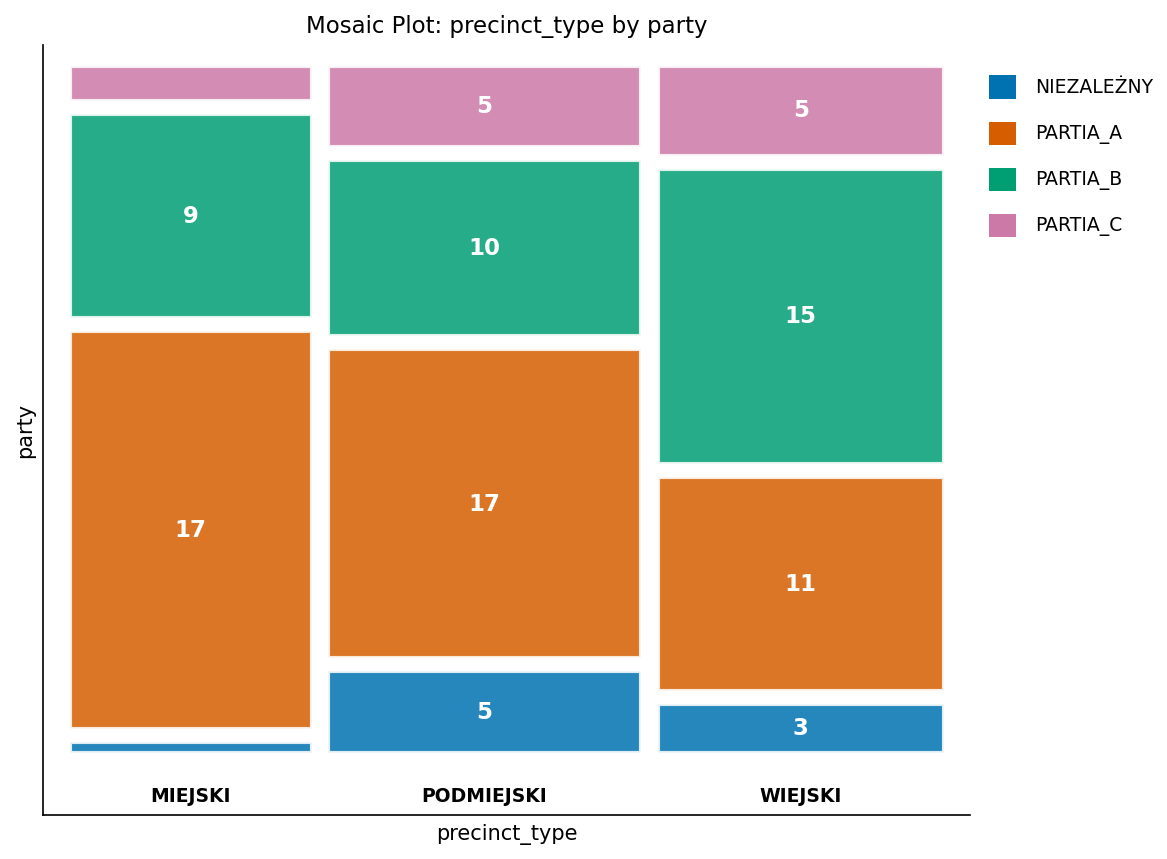

In [7]:
/* --------------------------------------------------------
   Eksportuj podsumowanie typ obwodu x partia do dalszej oceny
   wpływu zmiany granic okręgów.
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
WYKONAJ;

PROCEDURA EKSPORTUJ DANE=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
WYKONAJ;


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Napędzane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>